# Tutorial 7. Machine-learning interatomic potentials for molecular dynamics

## Goal of the notebook

This notebook demonstrates how molecular dynamics simulations of a catalytic interface can be performed using a machine-learning interatomic potential (MACE).

## Description of the method

MACE (Message Passing Atomic Cluster Expansion) is a machine-learning interatomic potential trained on DFT data that predicts energies and forces for atomic systems. It combines cluster expansion physics with message-passing neural networks, allowing efficient simulations of large systems and long molecular-dynamics trajectories while maintaining near-DFT accuracy.

MACE github: https://github.com/ACEsuit/mace

MACE article: Batatia, I.; Kovács, D. P.; Simm, G. N. C.; Ortner, C.; Csányi, G. MACE: Higher Order Equivariant Message Passing Neural Networks for Fast and Accurate Force Fields. J. Chem. Phys. 2023. https://doi.org/10.48550/arXiv.2206.07697

## Outline of theWorkflow

STEP 1. Preparing the Pt–OH–H₂O interface

STEP 2. Load the pretrained MACE potential and attach it as the calculator.

STEP 3. Run molecular dynamics simulations using ML-predicted forces.

STEP 4. Analyze the atomic trajectory to observe the dynamic behavior of water near the catalytic surface.



## Installation of packages


First things first, we need to install the packages and import the neccessary functions. We need ASE, Torch and MACE

In [ ]:
method='mace'
prefix='Pt-32H2O_MD'

Next we import the necessary packages:

ASE https://ase-lib.org/

MACE: https://github.com/ACEsuit/mace

Torch: https://github.com/pytorch/pytorch

In [4]:
from ase import units
from ase.constraints import FixAtoms
from ase.io import read, write, Trajectory
from ase.md.langevin import Langevin
from ase.units import fs
from ase.visualize import view
from mace.calculators import MACECalculator
from PIL import Image
import imageio
import torch
import os
from IPython.display import Image as IPImage


/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


##STEP 1. Preparing the Pt–OH–H₂O interface

In this step we obtain the MACE calculator from GitHub and download the Pt(111)–OH–H₂O interface structure that will be used in the simulation. The structure is loaded into ASE and prepared as the starting configuration for the molecular dynamics simulation.

In [5]:
%%capture
!wget https://raw.githubusercontent.com/vilab-tartu/test_models/refs/heads/main/Pt-w/Pt-32H2O_MD.xyz
!wget https://github.com/ACEsuit/mace-mp/releases/download/mace_mp_0b/mace_agnesi_small.model

View the structure

In [6]:
atoms = read(f'{prefix}.xyz')
view(atoms, viewer='x3d')

Fix all the atoms with tag = 1 (Pt)

In [7]:
pt_indices = [atom.index for atom in atoms if atom.tag == 1]
atoms.set_constraint(FixAtoms(indices=pt_indices))

##STEP 2. Load the pretrained MACE potential and attach it as the calculator.

The pretrained MACE model is loaded and assigned as the calculator for the system. The model predicts energies and forces for the atomic configuration, replacing conventional DFT calculations during the simulation.

In [8]:
model_path = "mace_agnesi_small.model"
atoms.calc = MACECalculator(model_paths=model_path, use_cu_eq=False)

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


##STEP 3. Running molecular dynamics

Using the forces predicted by the MACE potential, a molecular dynamics simulation is performed. During the simulation the atomic positions evolve over time, allowing us to observe the movement of water molecules and their interactions with the catalytic surface.

In [9]:
dyn = Langevin(
    atoms,
    timestep=1.0 * fs,
    temperature_K=300.0,
    friction=0.01 / fs,
)

output_traj_file = f'{prefix}.traj'
traj = Trajectory(output_traj_file, 'w', atoms)
dyn.attach(traj.write, interval=1)

dyn.run(100)

##STEP 4. Analyzing the trajectory

The generated trajectory is analyzed to examine the structure and dynamics of the interfacial water layer. This allows visualization of hydrogen bonding, adsorption stability, and the dynamic rearrangement of molecules near the Pt surface.

In [10]:
def trajectory_to_gif(traj_path, gif_name, rotation='-90x,90y,0z', show_unit_cell=0, duration=5.1):
    trajectory = read(traj_path, index=":")
    png_files = []

    # Write each frame as PNG
    for i, atoms in enumerate(trajectory):
        filename = f"frame_{i:04d}.png"
        write(filename, atoms, show_unit_cell=show_unit_cell, rotation=rotation)
        png_files.append(filename)

    # Prepare images with white background for GIF
    base_size = Image.open(png_files[0]).size
    images = []
    for fname in png_files:
        im = Image.open(fname).convert("RGBA")
        background = Image.new("RGBA", im.size, (255, 255, 255, 255))
        combined = Image.alpha_composite(background, im).convert("RGB")
        images.append(combined.resize(base_size))

    # Save GIF
    imageio.mimsave(gif_name, images, duration=duration)

    # Cleanup PNG files
    for fname in png_files:
        os.remove(fname)
    print(f"GIF saved as {gif_name}")

# Create GIF from trajectory
trajectory_to_gif(f'{prefix}.traj', f"{prefix}_{method}.gif")

GIF saved as Pt-32H2O_MD_mace.gif


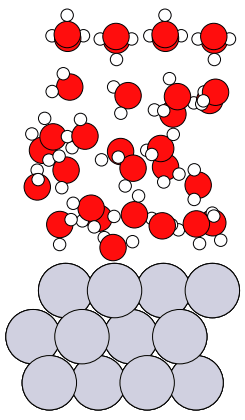

In [19]:
IPImage(f"{prefix}_{method}.gif")

##Conclusive remarks

In this tutorial, we started from a Pt(111)–OH–H₂O interface model representing a realistic electrochemical environment. The structure was loaded into ASE and the MACE machine-learning interatomic potential was attached as the calculator. Using ML-predicted energies and forces, a molecular dynamics simulation was performed to explore the time evolution of the system. The resulting trajectory illustrates how water molecules dynamically interact with the catalytic surface and the OH adsorbate.

After completing this tutorial, you will be able to:

Perform molecular dynamics simulations of catalytic interfaces using machine-learning interatomic potentials.

Load and apply pretrained MACE models within an ASE simulation workflow.

Analyze trajectories from MD simulations to study the dynamic behavior of solvent molecules near catalytic surfaces.

Use ML potentials to extend atomistic simulations to time scales that are difficult to access with conventional DFT methods.